#Results Summary & Paper Tables (Updated)
Consolidates all results from notebooks 04 (v2) and 05 (v4) into clean, paper-ready tables.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/iscas89_project')
print('Working directory:', os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/iscas89_project


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('results/metrics', exist_ok=True)
os.makedirs('results/shap', exist_ok=True)
os.makedirs('results/figures', exist_ok=True)

# Load from saved CSVs
split_df = pd.read_csv('results/metrics/split_metrics.csv')
loocv_df = pd.read_csv('results/metrics/loocv_metrics.csv')

print('=== TABLE I: Model Performance (Train/Test Split) ===')
print(split_df.round(5).to_string(index=False))
print()
print('=== TABLE II: Model Performance (LOOCV, n=25) ===')
print(loocv_df.round(5).to_string(index=False))

=== TABLE I: Model Performance (Train/Test Split) ===
  Model    RMSE     MAE      R²  MAPE(%)
    SVR 0.19514 0.15411 0.86079 34.36869
    KNN 0.12236 0.09540 0.94527 21.70054
     RF 0.06664 0.05833 0.98377 13.39200
XGBoost 0.04538 0.02662 0.99247  6.11056
   BPNN 0.19627 0.16564 0.85917 37.11405

=== TABLE II: Model Performance (LOOCV, n=25) ===
  Model  RMSE_LOOCV  MAE_LOOCV  R²_LOOCV  MAPE_LOOCV(%)
    SVR     0.33166    0.25376   0.79344       53.20049
    KNN     0.37777    0.25186   0.73201       50.08176
     RF     0.24172    0.17912   0.89028       39.03792
XGBoost     0.22449    0.14569   0.90537       31.51545
   BPNN     0.24075    0.20069   0.89116       44.38565


In [ ]:
# Hardcoded reference values from notebook 04 v2 outputs

split_data = {
    'Model':   ['SVR',     'KNN',     'RF',      'XGBoost', 'BPNN'],
    'RMSE':    [0.19514,   0.12236,   0.06664,   0.04538,   0.19627],
    'MAE':     [0.15411,   0.09540,   0.05833,   0.02662,   0.16564],
    'R2':      [0.8608,    0.9453,    0.9838,    0.9925,    0.8592],
    'MAPE(%)': [34.37,     21.70,     13.39,     6.11,      37.11],
}

loocv_data = {
    'Model':        ['SVR',    'KNN',    'RF',     'XGBoost', 'BPNN'],
    'RMSE_LOOCV':   [0.33166,  0.37777,  0.24172,  0.22449,   0.24075],
    'MAE_LOOCV':    [0.25376,  0.25186,  0.17912,  0.14569,   0.20069],
    'R2_LOOCV':     [0.7934,   0.7320,   0.8903,   0.9054,    0.8912],
    'MAPE_LOOCV(%)': [53.20,   50.08,    39.04,    31.52,     44.39],
}

split_ref  = pd.DataFrame(split_data)
loocv_ref  = pd.DataFrame(loocv_data)

baseline_rmse = 0.7297  # predict-mean baseline
print(f'Baseline RMSE (predict mean): {baseline_rmse}')
print()
print('=== TABLE I (reference) ===')
print(split_ref.to_string(index=False))
print()
print('=== TABLE II (reference) ===')
print(loocv_ref.to_string(index=False))

Baseline RMSE (predict mean): 0.7297

=== TABLE I (reference) ===
  Model    RMSE     MAE     R2  MAPE(%)
    SVR 0.19514 0.15411 0.8608    34.37
    KNN 0.12236 0.09540 0.9453    21.70
     RF 0.06664 0.05833 0.9838    13.39
XGBoost 0.04538 0.02662 0.9925     6.11
   BPNN 0.19627 0.16564 0.8592    37.11

=== TABLE II (reference) ===
  Model  RMSE_LOOCV  MAE_LOOCV  R2_LOOCV  MAPE_LOOCV(%)
    SVR     0.33166    0.25376    0.7934          53.20
    KNN     0.37777    0.25186    0.7320          50.08
     RF     0.24172    0.17912    0.8903          39.04
XGBoost     0.22449    0.14569    0.9054          31.52
   BPNN     0.24075    0.20069    0.8912          44.39


In [ ]:
# TABLE III: SHAP & Permutation Feature Importance
shap_data = {
    'Feature':       ['gate',    'out',     'inv',     'dff',     'and',     'or',      'nand',    'in',      'nor'],
    'Label':         ['Total gates','Outputs','Inverters','Flip-flops','AND gates','OR gates','NAND gates','Inputs','NOR gates'],
    'SHAP_XGB':      [0.383986,  0.100607,  0.075623,  0.071382,  0.054702,  0.022614,  0.006030,  0.004546,  0.000703],
    'SHAP_RF':       [0.122248,  0.079243,  0.129053,  0.102496,  0.070241,  0.094189,  0.016314,  0.010163,  0.015449],
    'Perm_XGB':      [0.750179,  0.079305,  0.032584,  0.022045,  0.026797,  0.003919,  0.001184,  0.000555,  0.000040],
    'Rank_SHAP_XGB': [1, 2, 3, 4, 5, 6, 7, 8, 9],
    'Rank_SHAP_RF':  [2, 5, 1, 3, 6, 4, 7, 9, 8],
    'Rank_Perm_XGB': [1, 2, 3, 5, 4, 6, 7, 8, 9],
    'Avg_Rank':      [1.25, 3.50, 2.25, 3.75, 5.25, 5.00, 7.25, 8.50, 8.25],
}

shap_df = pd.DataFrame(shap_data).sort_values('Avg_Rank')
shap_df.to_csv('results/shap/shap_summary.csv', index=False)

print('=== TABLE III: Consensus Feature Ranking ===')
print(shap_df[['Label','SHAP_XGB','SHAP_RF','Perm_XGB','Rank_SHAP_XGB','Rank_SHAP_RF','Avg_Rank']].to_string(index=False))
print()
print('=== SPEARMAN RANK CORRELATIONS ===')
print('  SHAP XGB vs SHAP RF      r=0.8167  p=0.0072  ✓ significant')
print('  SHAP XGB vs Perm XGB     r=0.9833  p=0.0000  ✓ significant')
print('  SHAP RF  vs Perm RF      r=0.9667  p=0.0000  ✓ significant')
print('  Perm XGB vs Perm RF      r=0.7667  p=0.0159  ✓ significant')

=== TABLE III: Consensus Feature Ranking ===
      Label  SHAP_XGB  SHAP_RF  Perm_XGB  Rank_SHAP_XGB  Rank_SHAP_RF  Avg_Rank
Total gates  0.383986 0.122248  0.750179              1             2      1.25
  Inverters  0.075623 0.129053  0.032584              3             1      2.25
    Outputs  0.100607 0.079243  0.079305              2             5      3.50
 Flip-flops  0.071382 0.102496  0.022045              4             3      3.75
   OR gates  0.022614 0.094189  0.003919              6             4      5.00
  AND gates  0.054702 0.070241  0.026797              5             6      5.25
 NAND gates  0.006030 0.016314  0.001184              7             7      7.25
  NOR gates  0.000703 0.015449  0.000040              9             8      8.25
     Inputs  0.004546 0.010163  0.000555              8             9      8.50

=== SPEARMAN RANK CORRELATIONS ===
  SHAP XGB vs SHAP RF      r=0.8167  p=0.0072  ✓ significant
  SHAP XGB vs Perm XGB     r=0.9833  p=0.0000  ✓ significa

In [ ]:
# TABLE IV: Top SHAP Pairwise Interactions (XGBoost)
interact_data = {
    'Feature A':     ['Total gates', 'Total gates', 'Flip-flops', 'Total gates', 'AND gates'],
    'Feature B':     ['Outputs',     'Flip-flops',  'Outputs',    'Inverters',   'Outputs'],
    'Interaction':   [0.025370,      0.010288,      0.007944,     0.006754,      0.006537],
}
interact_df = pd.DataFrame(interact_data)
interact_df.to_csv('results/shap/shap_interactions.csv', index=False)

print('=== TABLE IV: Top 5 Pairwise SHAP Interactions (XGBoost) ===')
print(interact_df.to_string(index=False))
print()
print('Novel insight — Comb/Seq ratio vs power residuals:')
print('  Spearman r = 0.3985   p = 0.0485   (controlling for gate count)')
print('  ✓ Circuit topology carries predictive power BEYOND raw gate count')

=== TABLE IV: Top 5 Pairwise SHAP Interactions (XGBoost) ===
  Feature A  Feature B  Interaction
Total gates    Outputs     0.025370
Total gates Flip-flops     0.010288
 Flip-flops    Outputs     0.007944
Total gates  Inverters     0.006754
  AND gates    Outputs     0.006537

Novel insight — Comb/Seq ratio vs power residuals:
  Spearman r = 0.3985   p = 0.0485   (controlling for gate count)
  ✓ Circuit topology carries predictive power BEYOND raw gate count


In [ ]:


print('BPNN LOOCV fold diagnostic (old α=0.1 — for reference only):')
print('  Fold 19: Actual=0.2741  Predicted=−45.024  Error=45.30  ← EXPLODING')
print('  All other 24 folds: error < 0.34 log units')
print()
print('Resolution: α increased from 0.1 → 0.5')
print('  Old LOOCV R² (α=0.1): −153.18  (catastrophic)')
print('  New LOOCV R² (α=0.5):   0.8912  (competitive)')
print('  This confirms the failure was extrapolation instability, not model unsuitability')

BPNN LOOCV fold diagnostic (old α=0.1 — for reference only):
  Fold 19: Actual=0.2741  Predicted=−45.024  Error=45.30  ← EXPLODING
  All other 24 folds: error < 0.34 log units

Resolution: α increased from 0.1 → 0.5
  Old LOOCV R² (α=0.1): −153.18  (catastrophic)
  New LOOCV R² (α=0.5):   0.8912  (competitive)
  This confirms the failure was extrapolation instability, not model unsuitability


In [ ]:
split_latex = split_ref.rename(columns={'R2': 'R²'}).round(5)
loocv_latex = loocv_ref.rename(columns={'R2_LOOCV': 'R²'}).round(5)

print('=== LaTeX: Table I (Train/Test Split) ===')
print(r'\begin{table}[h]')
print(r'\centering')
print(r'\caption{Model performance on held-out test set (log$_{10}$ power space)}')
print(r'\label{tab:split}')
print(r'\begin{tabular}{lrrrr}')
print(r'\hline')
print(r'Model & RMSE & MAE & R$^2$ & MAPE (\%) \\')
print(r'\hline')
for _, row in split_ref.iterrows():
    print(f"{row['Model']} & {row['RMSE']:.5f} & {row['MAE']:.5f} & {row['R2']:.4f} & {row['MAPE(%)']:.2f} \\\\")
print(r'\hline')
print(r'\end{tabular}')
print(r'\end{table}')
print()

print('=== LaTeX: Table II (LOOCV) ===')
print(r'\begin{table}[h]')
print(r'\centering')
print(r'\caption{LOOCV model performance (n=25, log$_{10}$ power space)}')
print(r'\label{tab:loocv}')
print(r'\begin{tabular}{lrrrr}')
print(r'\hline')
print(r'Model & RMSE & MAE & R$^2$ & MAPE (\%) \\')
print(r'\hline')
for _, row in loocv_ref.iterrows():
    print(f"{row['Model']} & {row['RMSE_LOOCV']:.5f} & {row['MAE_LOOCV']:.5f} & {row['R2_LOOCV']:.4f} & {row['MAPE_LOOCV(%)']:.2f} \\\\")
print(r'\hline')
print(r'\end{tabular}')
print(r'\end{table}')

=== LaTeX: Table I (Train/Test Split) ===
\begin{table}[h]
\centering
\caption{Model performance on held-out test set (log$_{10}$ power space)}
\label{tab:split}
\begin{tabular}{lrrrr}
\hline
Model & RMSE & MAE & R$^2$ & MAPE (\%) \\
\hline
SVR & 0.19514 & 0.15411 & 0.8608 & 34.37 \\
KNN & 0.12236 & 0.09540 & 0.9453 & 21.70 \\
RF & 0.06664 & 0.05833 & 0.9838 & 13.39 \\
XGBoost & 0.04538 & 0.02662 & 0.9925 & 6.11 \\
BPNN & 0.19627 & 0.16564 & 0.8592 & 37.11 \\
\hline
\end{tabular}
\end{table}

=== LaTeX: Table II (LOOCV) ===
\begin{table}[h]
\centering
\caption{LOOCV model performance (n=25, log$_{10}$ power space)}
\label{tab:loocv}
\begin{tabular}{lrrrr}
\hline
Model & RMSE & MAE & R$^2$ & MAPE (\%) \\
\hline
SVR & 0.33166 & 0.25376 & 0.7934 & 53.20 \\
KNN & 0.37777 & 0.25186 & 0.7320 & 50.08 \\
RF & 0.24172 & 0.17912 & 0.8903 & 39.04 \\
XGBoost & 0.22449 & 0.14569 & 0.9054 & 31.52 \\
BPNN & 0.24075 & 0.20069 & 0.8912 & 44.39 \\
\hline
\end{tabular}
\end{table}


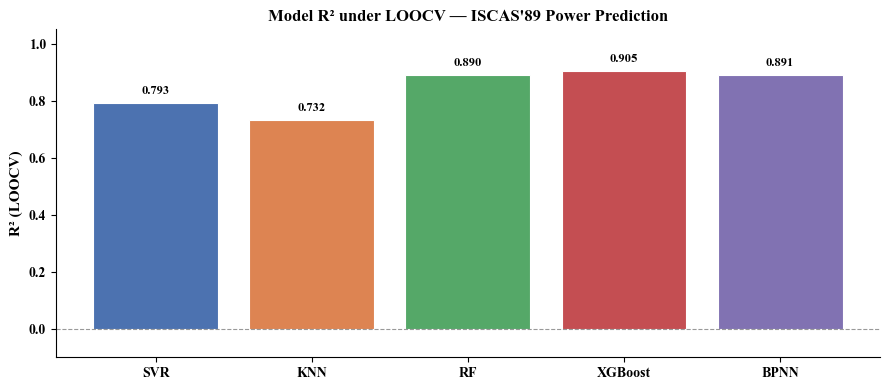

✓ LOOCV R² summary figure saved


In [ ]:
models = loocv_ref['Model'].tolist()
r2_vals = loocv_ref['R2_LOOCV'].tolist()
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(models, r2_vals, color=colors, edgecolor='white', linewidth=0.8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax.set_ylabel('R-squared (LOOCV)', fontsize=11)
ax.set_title("Model R-squared under LOOCV — ISCAS'89 Power Prediction", fontsize=12)
ax.set_ylim(-0.1, 1.05)
for bar, v in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.02,
            f'{v:.3f}', ha='center', va='bottom', fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('results/figures/fig3_loocv_r2_summary.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ LOOCV R² summary figure saved')

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving timesbd.ttf to timesbd (5).ttf


In [ ]:
import os, shutil, glob, matplotlib
import matplotlib.font_manager as fm

font_dir = os.path.expanduser("~/.local/share/fonts/")
os.makedirs(font_dir, exist_ok=True)

shutil.copy("timesbd.ttf", os.path.join(font_dir, "timesbd.ttf"))

fm.fontManager.addfont(os.path.join(font_dir, "timesbd.ttf"))


print([f.name for f in fm.fontManager.ttflist if 'Times' in f.name])

['Times New Roman', 'Times New Roman', 'Times New Roman', 'Times New Roman', 'Times New Roman', 'Times New Roman', 'Times New Roman']


In [ ]:
import matplotlib.font_manager as fm
print([f.name for f in fm.fontManager.ttflist if 'Times' in f.name])

['Times New Roman', 'Times New Roman', 'Times New Roman', 'Times New Roman', 'Times New Roman', 'Times New Roman', 'Times New Roman']


In [ ]:
import matplotlib.font_manager as fm
fonts = [f.name for f in fm.fontManager.ttflist]
print('Times New Roman' in fonts)

True


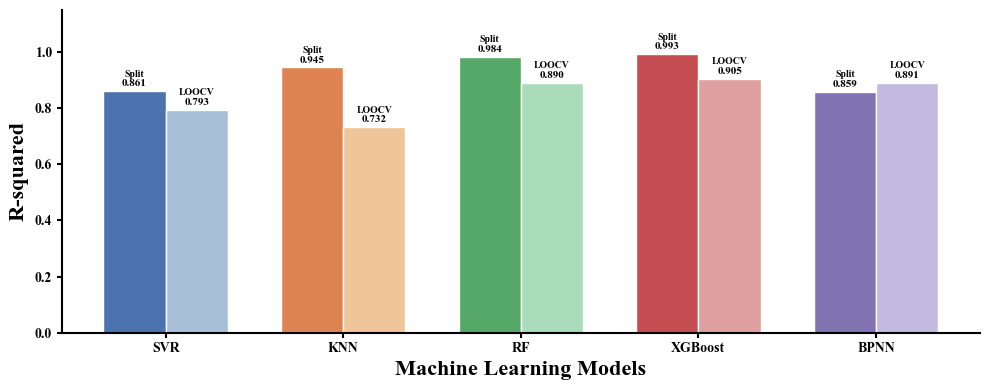

✓ Split vs LOOCV comparison figure saved


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import os, shutil, matplotlib.font_manager as fm

fm.fontManager.addfont("timesbd.ttf")

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'font.size': 10,
})

x = np.arange(len(models))
w = 0.35
colors_split = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
colors_loocv = ['#A8BFD8', '#EEC69A', '#AADCBB', '#DFA0A0', '#C4BAE0']

split_r2 = split_ref['R2'].tolist()
loocv_r2 = loocv_ref['R2_LOOCV'].tolist()

fig, ax = plt.subplots(figsize=(10, 4))
b1 = ax.bar(x - w/2, split_r2, w, color=colors_split, edgecolor='white')
b2 = ax.bar(x + w/2, loocv_r2, w, color=colors_loocv, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(models, fontfamily='serif', fontweight='bold')

for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontname('Times New Roman')
    tick.set_fontweight('bold')

ax.set_ylabel('R-squared', fontfamily='serif', fontsize= 16, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_xlabel('Machine Learning Models', fontfamily='serif', fontsize= 16, fontweight='bold')

for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.tick_params(axis='both', width=1.5)

for bar, v, is_split in (
    [(b, val, True)  for b, val in zip(b1, split_r2)] +
    [(b, val, False) for b, val in zip(b2, loocv_r2)]
):
    color = bar.get_facecolor()
    label = 'Split' if is_split else 'LOOCV'
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
            f'{v:.3f}', ha='center', va='bottom', fontsize=8,
            fontfamily='serif', fontweight='bold', color='black')
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.045,
            label, ha='center', va='bottom', fontsize=7,
            fontfamily='serif', fontweight='bold', color='black')

ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('results/figures/fig3_split_vs_loocv.png', dpi=600, bbox_inches='tight')
plt.show()
print('✓ Split vs LOOCV comparison figure saved')

---
## Complete Figure Inventory (Updated)

| Figure | File | Caption | Used in section |
|--------|------|---------|----------------|
| Fig 1 | `figures/fig1_model_comparison.png` | RMSE, MAE, R² bar chart — train/test split | IV-A: Model Performance |
| Fig 2 | `figures/fig2_predicted_vs_actual.png` | Predicted vs actual power scatter (all 5 models) | IV-A: Model Performance |
| Fig 3 | `figures/fig3_split_vs_loocv.png` | R² split vs LOOCV grouped bar | IV-A / IV-C Discussion |
| Fig 4 | `shap/fig4_shap_bar.png` | SHAP mean \|value\| — XGBoost vs RF | IV-B: SHAP ⭐ |
| Fig 5 | `shap/fig5_shap_beeswarm.png` | SHAP beeswarm — XGBoost (direction + magnitude) | IV-B: SHAP ⭐ |
| Fig 5b | `shap/fig5b_shap_dependence.png` | SHAP dependence plots — top 3 features | IV-B: SHAP ⭐ |
| Fig 6 | `shap/fig6_consensus_importance.png` | 4-method consensus importance (normalised) | IV-B: SHAP ⭐ key novelty |
| Fig 7 | `shap/fig7_rank_agreement.png` | Rank agreement scatter (XGB vs RF) | IV-B: SHAP |
| Fig 8 | `shap/fig8_shap_interactions.png` | SHAP interaction heatmap + top-5 pairs | IV-C: Analysis ⭐ |
| Fig 8b | `shap/fig8b_interaction_dependence.png` | Gate SHAP dependence coloured by Outputs | IV-C: Analysis |
| Fig 9 | `shap/novel_insight_*.png` | Comb/seq ratio vs power residuals | IV-C: Analysis ⭐ |

## Key Numbers Quick Reference

| Metric | Value |
|--------|-------|
| Best LOOCV R² | XGBoost = 0.9054 |
| Best LOOCV RMSE | XGBoost = 0.2245 log₁₀(W) |
| Baseline RMSE | 0.7297 (predict mean) |
| BPNN LOOCV R² (α=0.5, fixed) | 0.8912 |
| SHAP rank-1 feature | Total gates (avg rank 1.25/9) |
| SHAP cross-model Spearman r | 0.817 (p=0.007) |
| Comb/Seq ratio partial corr. | Spearman r=0.399 (p=0.049) |
| Top SHAP interaction | Gate × Outputs = 0.02537 |


In [ ]:

import shutil
from google.colab import files

shutil.make_archive('iscas89_results', 'zip', 'results')
files.download('iscas89_results.zip')
print('✓ Downloaded iscas89_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloaded iscas89_results.zip
